In [1]:
import pandas as pd

In [2]:
X_train = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_train.csv')
X_val   = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_val.csv')
X_test  = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/X_test.csv')
y_train = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_train.csv').squeeze()
y_val   = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_val.csv').squeeze()
y_test  = pd.read_csv(r'/kaggle/input/datasets/masterzero1/higgs-dat/y_test.csv').squeeze()

In [4]:
low_lvl_features = ['lepton  pT', 'lepton  eta', 'lepton  phi', 'missing energy magnitude', 'missing energy phi', 'jet 1 pt', 'jet 1 eta', 'jet 1 phi', 'jet 1 b-tag', 'jet 2 pt', 'jet 2 eta', 'jet 2 phi', 'jet 2 b-tag', 'jet 3 pt', 'jet 3 eta', 'jet 3 phi', 'jet 3 b-tag', 'jet 4 pt', 'jet 4 eta', 'jet 4 phi', 'jet 4 b-tag']
high_lvl_features = ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

#for xgboost
X_train_28 = X_train
X_train_21 = X_train.drop(high_lvl_features, axis=1)
X_train_7 = X_train.drop(low_lvl_features, axis=1)

X_val_28 = X_val
X_val_21 = X_val.drop(high_lvl_features, axis=1)
X_val_7 = X_val.drop(low_lvl_features, axis=1)

X_test_28 = X_test
X_test_21 = X_test.drop(high_lvl_features, axis=1)
X_test_7 = X_test.drop(low_lvl_features, axis=1)

# Parameters found from RandomizedSearchCV

Best params:  
  subsample: 0.9    
  reg_lambda: 1   
  reg_alpha: 0.1    
  n_estimators: 500   
  min_child_weight: 3   
  max_depth: 8    
  learning_rate: 0.1    
  gamma: 0    
  colsample_bytree: 0.7   
  
Best CV AUC: 0.8388   
Validation AUC: 0.8390  

In [ ]:
#Training the xgboost model on the parameters found from RandomizedSearchCV

#XGBoost (XGBClassifier)

from xgboost import XGBClassifier

#xgboost for 21 low level features
xgb_tuned_21 = XGBClassifier(
    subsample=0.9,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=10000,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    early_stopping_rounds=50,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)

xgb_tuned_21.fit(
    X_train_21,
    y_train,
    eval_set=[(X_val_21, y_val)],
    verbose=False)

#xgboost for 7 high level features
xgb_tuned_7 = XGBClassifier(
    subsample=0.9,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=2000,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    early_stopping_rounds=50,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)

xgb_tuned_7.fit(
    X_train_7,
    y_train,
    eval_set=[(X_val_7, y_val)],
    verbose=False)

#xgboost for all 28 features
xgb_tuned_28 = XGBClassifier(
    subsample=0.9,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=10000,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    early_stopping_rounds=50,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    device='cuda'
)

xgb_tuned_28.fit(
    X_train_28,
    y_train,
    eval_set=[(X_val_28, y_val)],
    verbose=False)

In [7]:
import shap

explainer_28 = shap.TreeExplainer(xgb_tuned_28)
shap_values_28 = explainer_28.shap_values(X_val_28)
print(shap_values_28.shape)

(550000, 28)


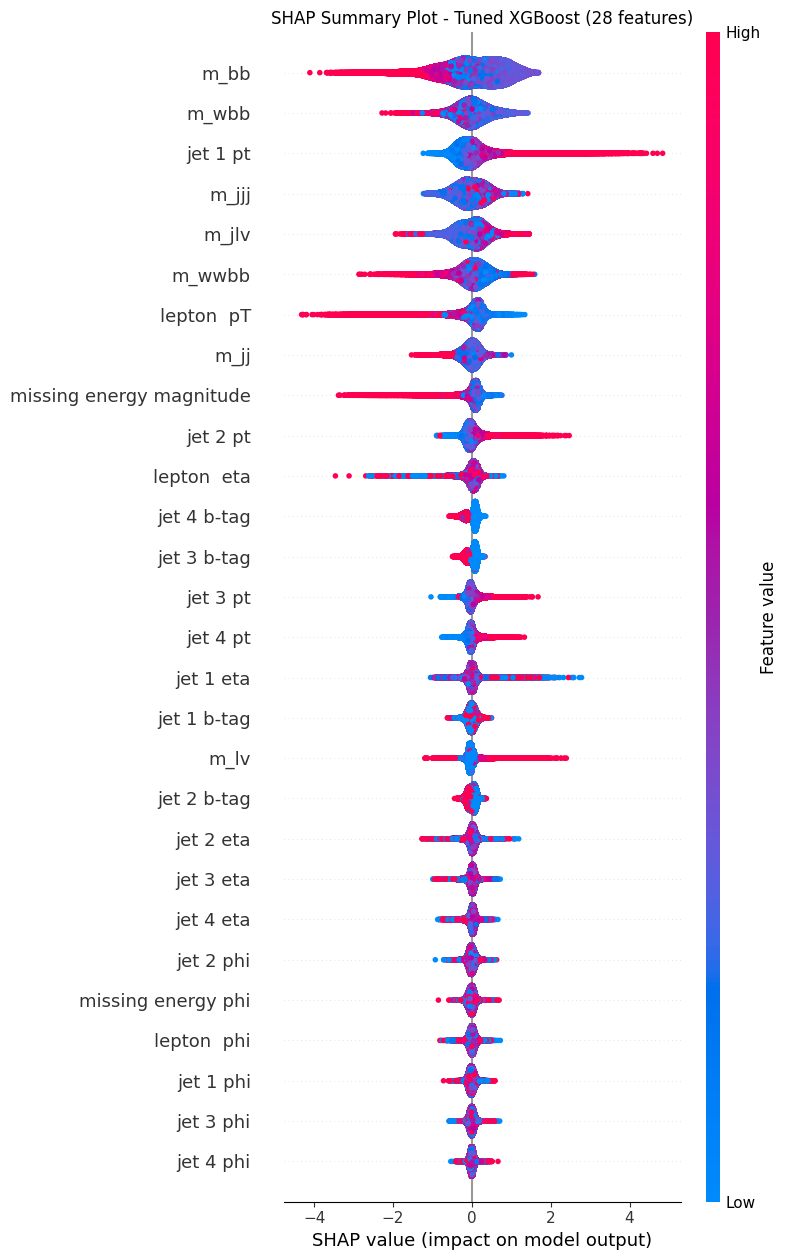

In [15]:
#Summary plot (28 features)

import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_28,
    X_val_28,
    max_display=28,
    show=False
)

plt.title("SHAP Summary Plot - Tuned XGBoost (28 features)")
plt.tight_layout()
plt.show()

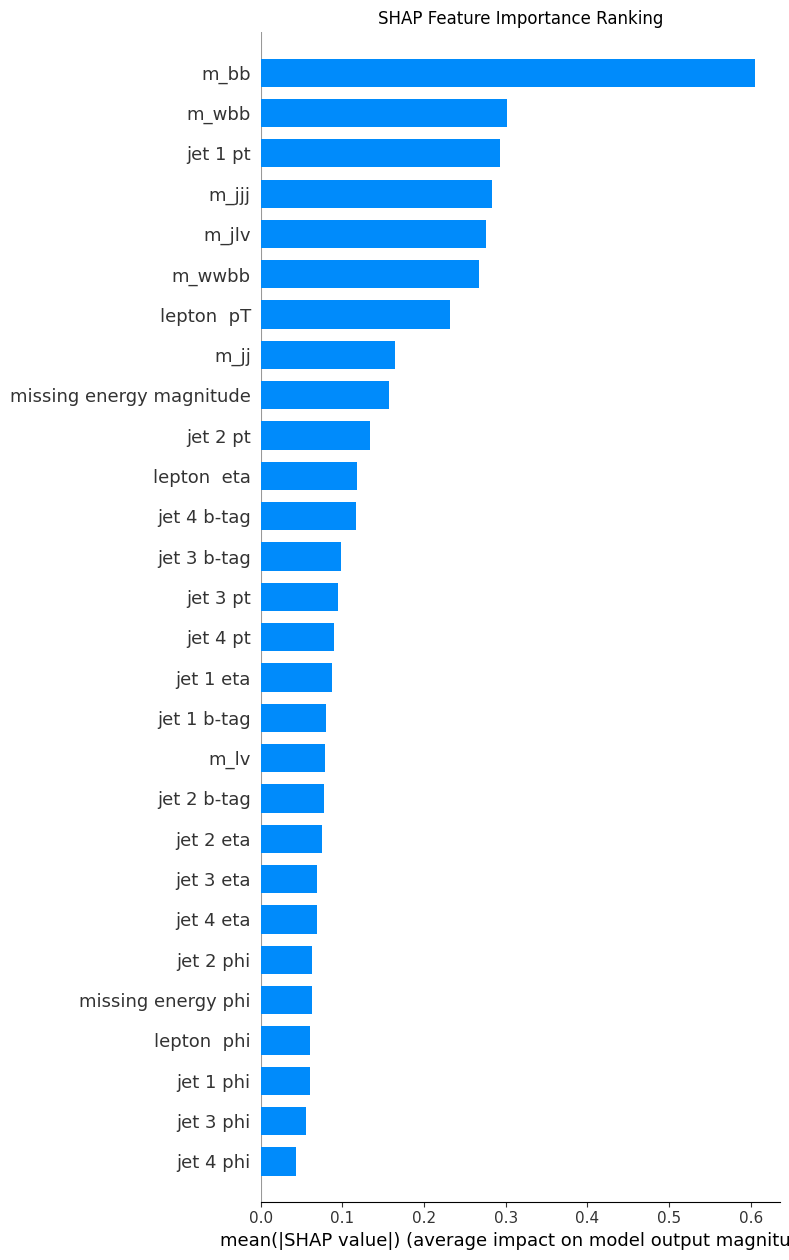

In [16]:
#Summary plot (28 features -> bar)

shap.summary_plot(
    shap_values_28,
    X_val_28,
    plot_type="bar",
    max_display=28,
    show=False
)

plt.title("SHAP Feature Importance Ranking")
plt.tight_layout()
plt.show()

In [17]:
# Importance features column
import numpy as np

importance_28 = pd.DataFrame({
    "features": X_val_28.columns,
    "MeanAbsSHAP": np.abs(shap_values_28).mean(axis=0)
})

importance_28 = importance_28.sort_values(
    "MeanAbsSHAP",
    ascending=False
)

print("\nTop 10 Most Important Features (28 Features)")
display(importance_28.head(28))


Top 10 Most Important Features (28 Features)


,features,MeanAbsSHAP
25,m_bb,0.605438
26,m_wbb,0.301321
5,jet 1 pt,0.293371
22,m_jjj,0.282922
24,m_jlv,0.275762
27,m_wwbb,0.266916
0,lepton pT,0.231519
21,m_jj,0.164770
3,missing energy magnitude,0.157070
9,jet 2 pt,0.133643



Most important feature overall: m_bb


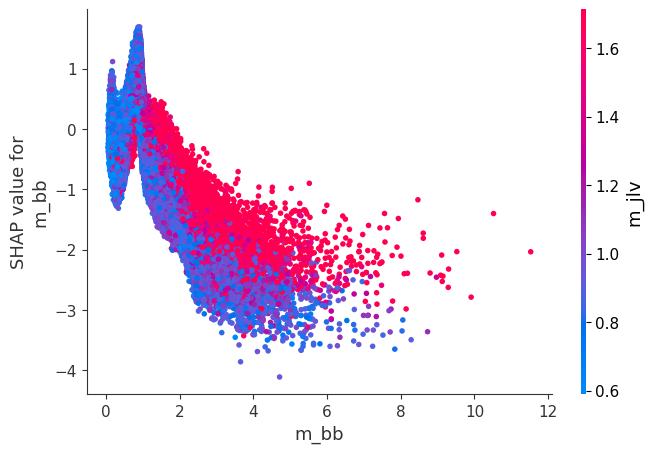

In [19]:
#Dependence plot (28 features, overall)

top_feature = importance_28.iloc[0]["features"]

print(f"\nMost important feature overall: {top_feature}")

shap.dependence_plot(
    top_feature,
    shap_values_28,
    X_val_28
)

In [20]:
explainer_7 = shap.TreeExplainer(xgb_tuned_7)
shap_values_7 = explainer_7.shap_values(X_val_7)

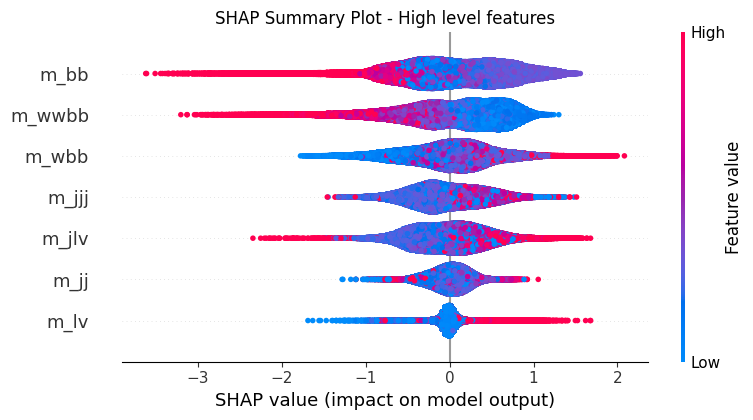

In [22]:
#Summary plot (7 features)

shap.summary_plot(
    shap_values_7,
    X_val_7,
    max_display=7,
    show=False
)

plt.title("SHAP Summary Plot - High level features")
plt.tight_layout()
plt.show()

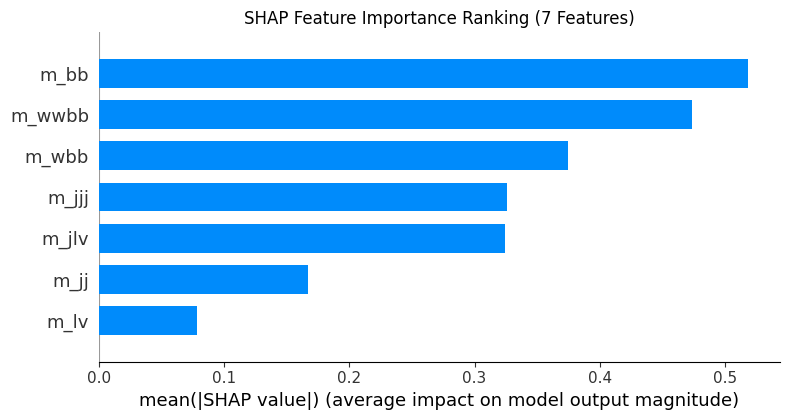

In [23]:
#Summary plot (7 features -> bar)

shap.summary_plot(
    shap_values_7,
    X_val_7,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance Ranking (7 Features)")
plt.tight_layout()
plt.show()

In [24]:

# Importance features table
importance_7 = pd.DataFrame({
    "features": X_val_7.columns,
    "MeanAbsSHAP": np.abs(shap_values_7).mean(axis=0)
})

importance_7 = importance_7.sort_values(
    "MeanAbsSHAP",
    ascending=False
)

print("\nFeature Importance Ranking (7 Features)")
display(importance_7)


Feature Importance Ranking (7 Features)


,features,MeanAbsSHAP
4,m_bb,0.518062
6,m_wwbb,0.473907
5,m_wbb,0.374891
1,m_jjj,0.325553
3,m_jlv,0.324584
0,m_jj,0.166964
2,m_lv,0.078743
